In [1]:

#by Henry Schumacher
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import time
start_setup = time.process_time_ns()
print('---------------------------------------')
print(time.strftime("pixe_cross.ipynb started: %a, %d %b %Y %H:%M:%S", time.localtime()))
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import os
import sys
import json
import uuid
import h5py
import math
import xraydb
import plotly
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import numpy as np
import pandas as pd
# import pyxray as xy
import odrpack as odr
import seaborn as sb
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from getmac import get_mac_address as gma
from itertools import chain
from matplotlib.offsetbox import OffsetImage, AnnotationBbox, TextArea, VPacker
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
from colors import load_colors
from PIXE_functions import *
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
## for Palatino and other serif fonts use:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times"],
    "text.usetex": True,
    "font.size": 8,
    "pgf.rcfonts": False
})


plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "pgf.preamble": "\n".join([
          r'\usepackage{amsmath}',
     ]),
})

#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
color_schemes = load_colors()


end_setup = time.process_time_ns()
elapsed_setup = (end_setup - start_setup)/1e6

print(f'INFO: SETUP COMPLETE ({elapsed_setup:.2f} ms)')
print('---------------------------------------')
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

---------------------------------------
pixe_cross.ipynb started: Wed, 29 Apr 2026 17:23:58
INFO: SETUP COMPLETE (1734.38 ms)
---------------------------------------


In [2]:
full_pixe_data = read_json_formatted_file(filepath="pixe_cross_data.json")


In [3]:
def single_element_data_plot(data:dict, start_val:list, elem:str, typeData:str='ECPSSR_data_alpha'):
    DPI = 250
    
    data_x = list(float(k) for k in data[elem][typeData].keys())[:-10]
    print(data[elem][typeData])
    data_y = list(v[0] for k in data[elem][typeData].keys() for v in data[elem][typeData][k])[:-10]
    print(data_x)
    print(data_y)
    data_x_err = np.array([0.01]*len(data_x))
    data_y_err = list(v[0]*(0.01*v[1]) for k in data[elem][typeData].keys() for v in data[elem][typeData][k])
    beta = evaluator_scipy(func=poly4_func, beta0_list=start_val, x=data_x, y=data_y, xerr=data_x_err, yerr=data_y_err)
    beta_export = [beta['param'],beta['errors']]
    xlin = np.linspace(np.min(data_x), np.max(data_x), 2000)
    
    plt.figure(figsize=(6,4), dpi=DPI)
    plt.scatter(data_x, data_y)
    plt.plot(xlin, poly4_func(beta_export[0],xlin))
    plt.ylim(1,2000)
    plt.xlim(0,10)
    # plt.yscale('log')
    plt.show()
    return 'lol'

{'0.5': [[0.0908, 6.6]], '0.6': [[0.213, 5.3]], '0.7': [[0.423, 5.3]], '0.8': [[0.749, 2.8]], '0.9': [[1.22, 2.8]], '1.0': [[1.87, 2.2]], '1.2': [[3.84, 1.6]], '1.4': [[6.92, 1.7]], '1.6': [[11.4, 1.7]], '1.8': [[17.4, 1.5]], '2.0': [[25.4, 1.5]], '2.3': [[41.1, 1.5]], '2.6': [[61.9, 1.4]], '3.0': [[98.4, 1.9]], '3.5': [[159.0, 1.9]], '4.0': [[235.0, 1.9]], '4.5': [[328.0, 2.9]], '5.5': [[555.0, 2.9]], '6.0': [[686.0, 2.9]], '7.0': [[977.0, 2.9]], '8.0': [[1290.0, 2.9]], '9.0': [[1620.0, 2.9]], '10.0': [[1960.0, 2.9]], '12.0': [[2630.0, 3.2]], '14.0': [[3260.0, 3.2]], '16.0': [[3830.0, 3.6]], '18.0': [[4340.0, 3.9]], '20.0': [[4800.0, 3.9]], '26.0': [[5840.0, 3.2]], '30.0': [[6310.0, 3.2]], '35.0': [[6730.0, 3.2]], '50.0': [[7210.0, 5.7]], '100.0': [[6430.0, 6.1]]}
[0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.3, 2.6, 3.0, 3.5, 4.0, 4.5, 5.5, 6.0, 7.0, 8.0, 9.0, 10.0]
[0.0908, 0.213, 0.423, 0.749, 1.22, 1.87, 3.84, 6.92, 11.4, 17.4, 25.4, 41.1, 61.9, 98.4, 159.0, 235.0, 328

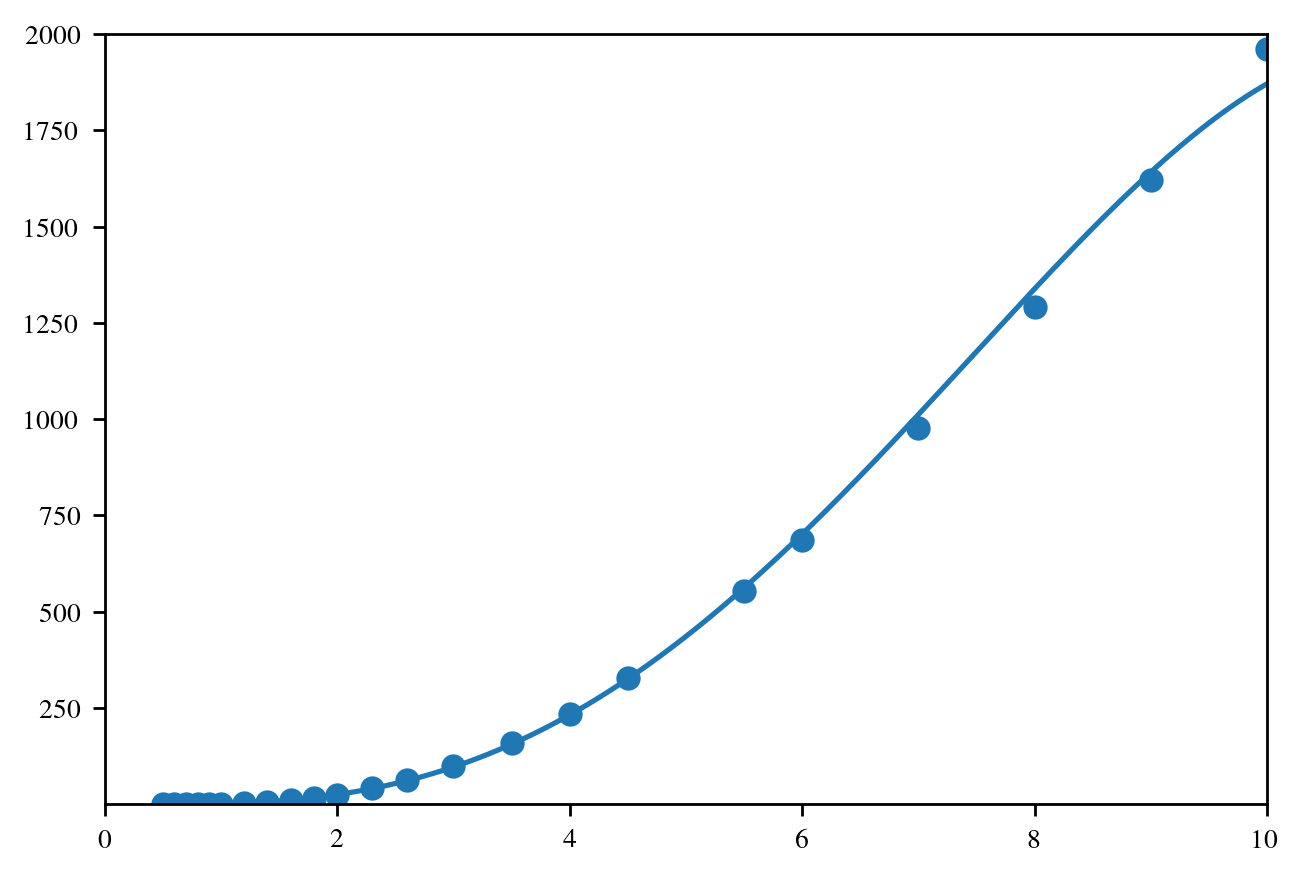

'lol'

In [4]:
s_val = [0,1,1,0,1]
single_element_data_plot(data=full_pixe_data, start_val=s_val, elem='Mn')

In [5]:
print(1.87-1347.9556+548.5239-42.4023)

-839.964
